In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
arts = pd.read_csv('../data/arts_sales.csv')
arts

,Year,Type,Sales
0,2022,Grocery Stores,854434
1,2021,Grocery Stores,790027
2,2020,Grocery Stores,756300
3,2019,Grocery Stores,690828
4,2022,Specialty Food Stores,25334
5,2021,Specialty Food Stores,24035
6,2020,Specialty Food Stores,21543
7,2019,Specialty Food Stores,20916
8,2022,Beer Wine Liquor Stores,69068
9,2021,Beer Wine Liquor Stores,68861


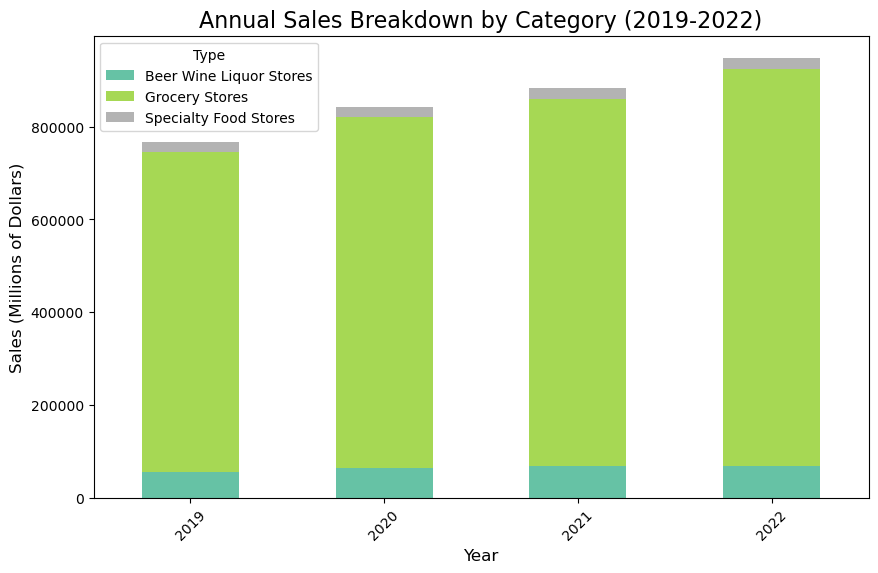

In [3]:
# Sample dataframe (replace this with your actual dataframe)
data = {
    'Year': [2022, 2021, 2020, 2019, 2022, 2021, 2020, 2019, 2022, 2021, 2020, 2019],
    'Type': ['Grocery Stores', 'Grocery Stores', 'Grocery Stores', 'Grocery Stores',
             'Specialty Food Stores', 'Specialty Food Stores', 'Specialty Food Stores', 'Specialty Food Stores',
             'Beer Wine Liquor Stores', 'Beer Wine Liquor Stores', 'Beer Wine Liquor Stores', 'Beer Wine Liquor Stores'],
    'Sales': [854434, 790027, 756300, 690828, 25334, 24035, 21543, 20916, 69068, 68861, 64709, 55418]
}

# Convert data into a DataFrame
df = pd.DataFrame(data)

# Pivot the DataFrame to get sales by year and category
df_pivot = df.pivot_table(index='Year', columns='Type', values='Sales', aggfunc='sum')

# Plotting the stacked bar chart
df_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')

# Add titles and labels
plt.title('Annual Sales Breakdown by Category (2019-2022)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sales (Millions of Dollars)', fontsize=12)

plt.xticks(rotation=45)
plt.show()

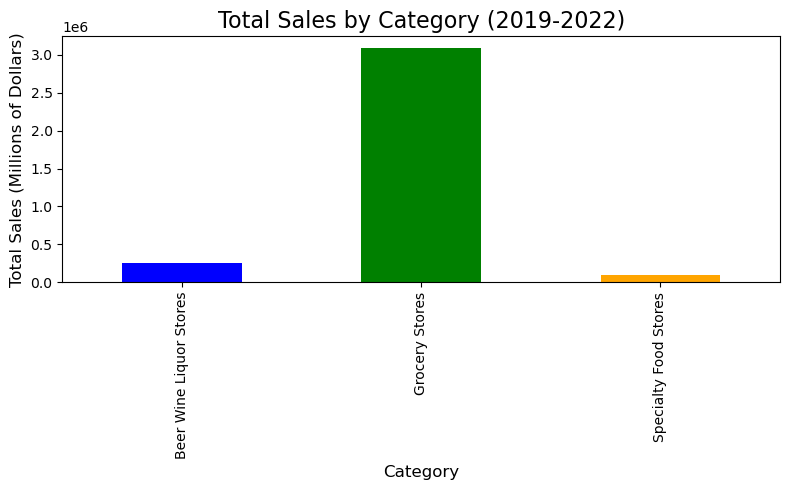

In [4]:
# Sample dataframe (replace this with your actual dataframe)
data = {
    'Year': [2022, 2021, 2020, 2019, 2022, 2021, 2020, 2019, 2022, 2021, 2020, 2019],
    'Type': ['Grocery Stores', 'Grocery Stores', 'Grocery Stores', 'Grocery Stores',
             'Specialty Food Stores', 'Specialty Food Stores', 'Specialty Food Stores', 'Specialty Food Stores',
             'Beer Wine Liquor Stores', 'Beer Wine Liquor Stores', 'Beer Wine Liquor Stores', 'Beer Wine Liquor Stores'],
    'Sales': [854434, 790027, 756300, 690828, 25334, 24035, 21543, 20916, 69068, 68861, 64709, 55418]
}

# Convert data into a DataFrame
df = pd.DataFrame(data)

# Sum sales for each category over the years (2019-2022)
sales_by_category = df.groupby('Type')['Sales'].sum()

# Plotting the bar chart
sales_by_category.plot(kind='bar', figsize=(8, 5), color=['blue', 'green', 'orange'])

# Add titles and labels
plt.title('Total Sales by Category (2019-2022)', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales (Millions of Dollars)', fontsize=12)

# Display the chart
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

In [5]:
df_filtered = df[df['Year'].isin([2019, 2022])]

In [6]:
pivot_df = df_filtered.pivot(index='Type', columns='Year', values='Sales')

In [7]:
pivot_df['Percent Growth'] = ((pivot_df[2022] - pivot_df[2019]) / pivot_df[2019]) * 100

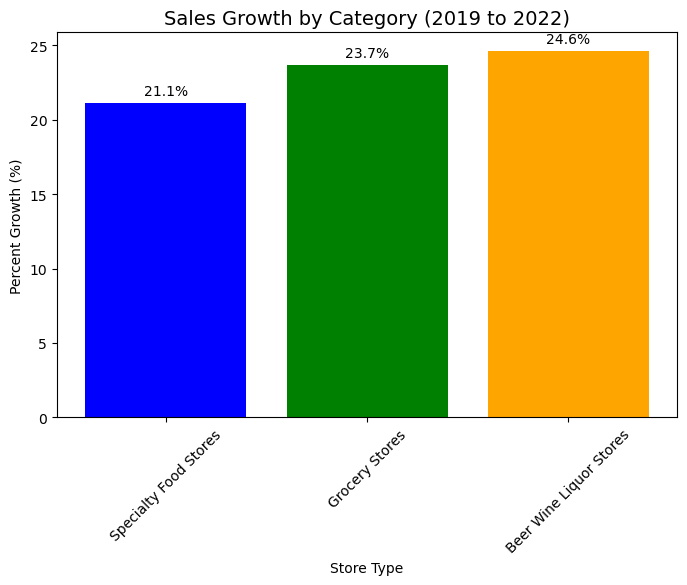

In [8]:
growth = pivot_df['Percent Growth'].sort_values()

plt.figure(figsize=(8, 5))
bars = plt.bar(growth.index, growth.values, color=['blue', 'green', 'orange'])  

plt.title('Sales Growth by Category (2019 to 2022)', fontsize=14)
plt.ylabel('Percent Growth (%)')
plt.xlabel('Store Type')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center')
plt.savefig('sales_growth_by_category.png', dpi=300, bbox_inches='tight')

plt.show()

In [9]:
df_filtered = df[df['Year'].isin([2019, 2020, 2021, 2022])]

In [10]:
pivot_df = df_filtered.pivot(index='Year', columns='Type', values='Sales')

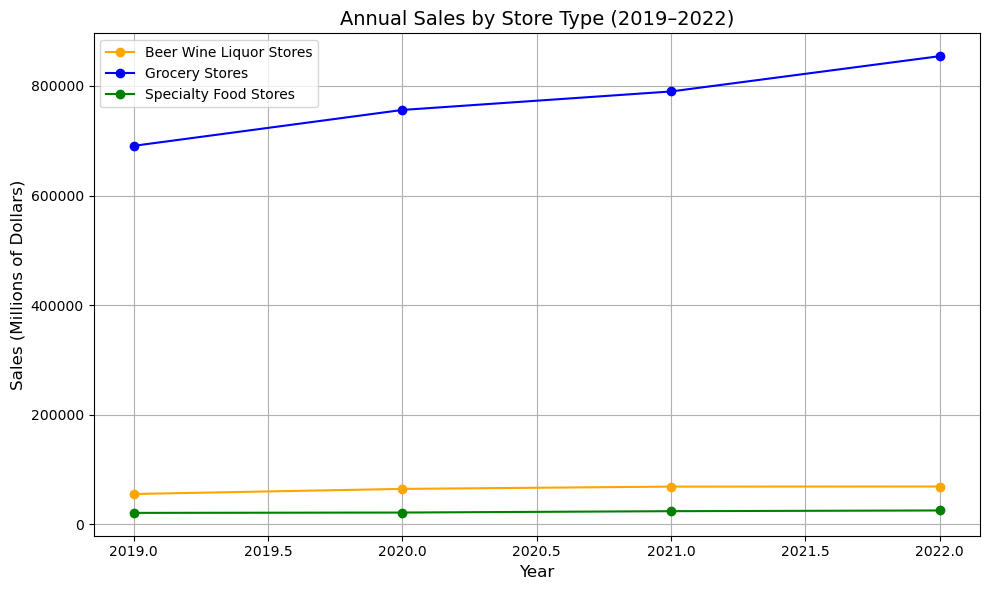

In [11]:
colors = {
    'Grocery Stores': 'blue',
    'Specialty Food Stores': 'green',
    'Beer Wine Liquor Stores': 'orange'
}

plt.figure(figsize=(10, 6))

# Plot each store type
for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], marker='o', label=column, color=colors[column])

plt.title('Annual Sales by Store Type (2019–2022)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sales (Millions of Dollars)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()